# COMP30027 Project 2 — Image Classification

Task 1 (10 animal classes, coarse) and Task 2 (10 bird species, fine-grained). Run cells top to bottom. Phase 3 (ResNet50) is cached, so re-runs are fast.

## 0. Setup

Imports, random seeds, and project paths.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Set random seed for reproducibility
np.random.seed(42)

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "code" else os.getcwd()  # repo root
TASK1_DIR = PROJECT_ROOT + "/task1_data/task1_data"
TASK2_DIR = PROJECT_ROOT + "/task2_data/task2_data"
FIG_DIR = PROJECT_ROOT + "/outputs/figures"
RES_DIR = PROJECT_ROOT + "/outputs/results"
CACHE_DIR = PROJECT_ROOT + "/outputs/cache"

# Make sure output dirs exist
for d in [FIG_DIR, RES_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

print("Setup done.")
print("PROJECT_ROOT =", PROJECT_ROOT)

Setup done.
PROJECT_ROOT = D:/2026S1/COMP30027/Assignment2


## Phase 1 — Data loading and EDA

In [2]:
# === Task 1: load metadata ===
train_meta_t1 = pd.read_csv(TASK1_DIR + "/train_metadata.csv")
test_meta_t1 = pd.read_csv(TASK1_DIR + "/test_metadata.csv")

# Class id <-> class name (sorted by class_id)
class_pairs_t1 = train_meta_t1[["class_id", "class_name"]].drop_duplicates().sort_values("class_id")
class_names_t1 = class_pairs_t1["class_name"].tolist()

print("Task 1 train metadata shape:", train_meta_t1.shape)
print("Task 1 test metadata shape:", test_meta_t1.shape)
print("Task 1 classes (10):", class_names_t1)

Task 1 train metadata shape: (3750, 4)
Task 1 test metadata shape: (1250, 2)
Task 1 classes (10): ['bird', 'butterfly', 'cat', 'deer', 'dog', 'elephant', 'frog', 'horse', 'sheep', 'spider']


In [3]:
# === Task 1: load feature CSVs and split train/test ===
color_hist_t1_full = pd.read_csv(TASK1_DIR + "/color_histogram.csv").set_index("image_id")
hog_pca_t1_full    = pd.read_csv(TASK1_DIR + "/hog_pca.csv").set_index("image_id")
extra_t1_full      = pd.read_csv(TASK1_DIR + "/additional_features.csv").set_index("image_id")

train_ids_t1 = train_meta_t1["image_id"].tolist()
test_ids_t1  = test_meta_t1["image_id"].tolist()

X1_color = color_hist_t1_full.loc[train_ids_t1].to_numpy(dtype=np.float32)
X1_hog   = hog_pca_t1_full.loc[train_ids_t1].to_numpy(dtype=np.float32)
X1_extra = extra_t1_full.loc[train_ids_t1].to_numpy(dtype=np.float32)
y1 = train_meta_t1["class_id"].to_numpy()

X1_color_test = color_hist_t1_full.loc[test_ids_t1].to_numpy(dtype=np.float32)
X1_hog_test   = hog_pca_t1_full.loc[test_ids_t1].to_numpy(dtype=np.float32)
X1_extra_test = extra_t1_full.loc[test_ids_t1].to_numpy(dtype=np.float32)

print("Task 1 train: color", X1_color.shape, " hog", X1_hog.shape, " extra", X1_extra.shape, " y", y1.shape)
print("Task 1 test:  color", X1_color_test.shape, " hog", X1_hog_test.shape, " extra", X1_extra_test.shape)

Task 1 train: color

 (3750, 96)  hog (3750, 100)  extra (3750, 23)  y (3750,)
Task 1 test:  color (1250, 96)  hog (1250, 100)  extra (1250, 23)


In [4]:
# === Task 2: same pattern ===
train_meta_t2 = pd.read_csv(TASK2_DIR + "/train_metadata.csv")
test_meta_t2 = pd.read_csv(TASK2_DIR + "/test_metadata.csv")

class_pairs_t2 = train_meta_t2[["class_id", "class_name"]].drop_duplicates().sort_values("class_id")
class_names_t2 = class_pairs_t2["class_name"].tolist()

color_hist_t2_full = pd.read_csv(TASK2_DIR + "/color_histogram.csv").set_index("image_id")
hog_pca_t2_full    = pd.read_csv(TASK2_DIR + "/hog_pca.csv").set_index("image_id")
extra_t2_full      = pd.read_csv(TASK2_DIR + "/additional_features.csv").set_index("image_id")

train_ids_t2 = train_meta_t2["image_id"].tolist()
test_ids_t2  = test_meta_t2["image_id"].tolist()

X2_color = color_hist_t2_full.loc[train_ids_t2].to_numpy(dtype=np.float32)
X2_hog   = hog_pca_t2_full.loc[train_ids_t2].to_numpy(dtype=np.float32)
X2_extra = extra_t2_full.loc[train_ids_t2].to_numpy(dtype=np.float32)
y2 = train_meta_t2["class_id"].to_numpy()

X2_color_test = color_hist_t2_full.loc[test_ids_t2].to_numpy(dtype=np.float32)
X2_hog_test   = hog_pca_t2_full.loc[test_ids_t2].to_numpy(dtype=np.float32)
X2_extra_test = extra_t2_full.loc[test_ids_t2].to_numpy(dtype=np.float32)

print("Task 2 classes (10):", class_names_t2)
print("Task 2 train: color", X2_color.shape, " hog", X2_hog.shape, " extra", X2_extra.shape, " y", y2.shape)
print("Task 2 test:  color", X2_color_test.shape, " hog", X2_hog_test.shape, " extra", X2_extra_test.shape)

Task 2 classes (10): ['American_Goldfinch', 'Blue_Jay', 'Cardinal', 'Herring_Gull', 'House_Sparrow', 'Red_winged_Blackbird', 'Ring_billed_Gull', 'Song_Sparrow', 'Wilson_Warbler', 'Yellow_Warbler']
Task 2 train: color (417, 96)  hog (417, 100)  extra (417, 23)  y (417,)
Task 2 test:  color (180, 96)  hog (180, 100)  extra (180, 23)


In [5]:
# Class distribution in training sets
print("Task 1 class counts:")
for cid in range(10):
    print(f"  {cid} {class_names_t1[cid]:25s} {np.sum(y1 == cid)}")

print("\nTask 2 class counts:")
for cid in range(10):
    print(f"  {cid} {class_names_t2[cid]:25s} {np.sum(y2 == cid)}")

Task 1 class counts:
  0 bird                      375
  1 butterfly                 375
  2 cat                       375
  3 deer                      375
  4 dog                       375
  5 elephant                  375
  6 frog                      375
  7 horse                     375
  8 sheep                     375
  9 spider                    375

Task 2 class counts:
  0 American_Goldfinch        42
  1 Blue_Jay                  42
  2 Cardinal                  39
  3 Herring_Gull              42
  4 House_Sparrow             42
  5 Red_winged_Blackbird      42
  6 Ring_billed_Gull          42
  7 Song_Sparrow              42
  8 Wilson_Warbler            42
  9 Yellow_Warbler            42


### 1.1 Class distribution

Task 1 is perfectly balanced (375 per class). Task 2 is near-balanced (Cardinal 39, others 42). Accuracy is a fair metric for both.

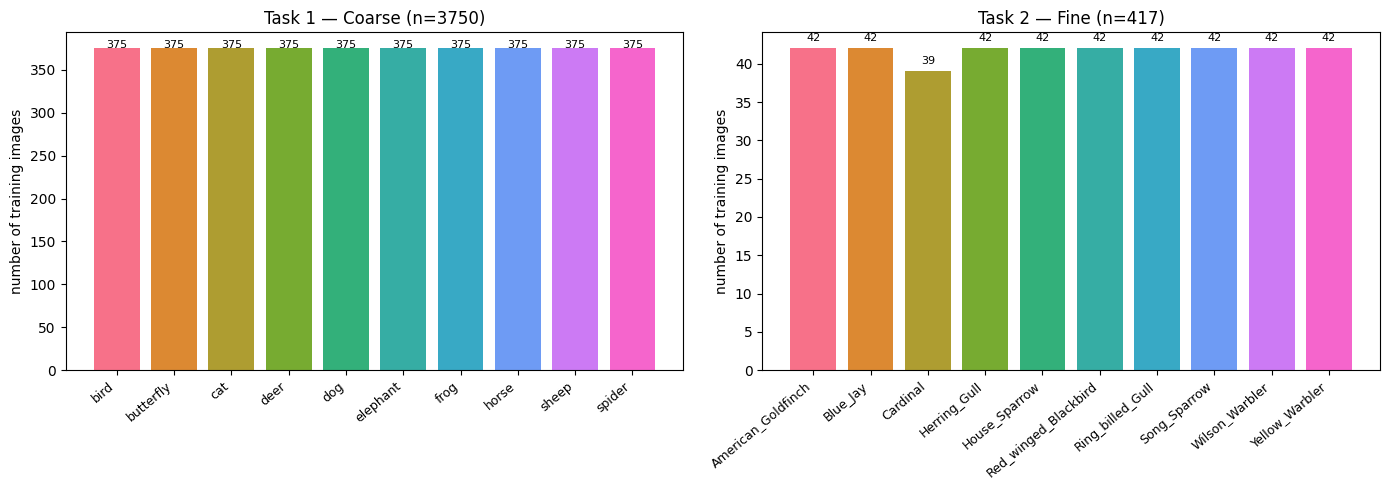

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Task 1
counts_t1 = np.bincount(y1, minlength=10)
axes[0].bar(range(10), counts_t1, color=sns.color_palette("husl", 10))
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(class_names_t1, rotation=40, ha="right", fontsize=9)
axes[0].set_ylabel("number of training images")
axes[0].set_title("Task 1 — Coarse (n=3750)")
for i, c in enumerate(counts_t1):
    axes[0].text(i, c + 1, str(c), ha="center", fontsize=8)

# Task 2
counts_t2 = np.bincount(y2, minlength=10)
axes[1].bar(range(10), counts_t2, color=sns.color_palette("husl", 10))
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(class_names_t2, rotation=40, ha="right", fontsize=9)
axes[1].set_ylabel("number of training images")
axes[1].set_title("Task 2 — Fine (n=417)")
for i, c in enumerate(counts_t2):
    axes[1].text(i, c + 1, str(c), ha="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Sample images per class

3 random training samples per class. Task 2's grid reveals the fine-grained challenge — pairs like Herring/Ring-billed Gull look nearly identical at this resolution.

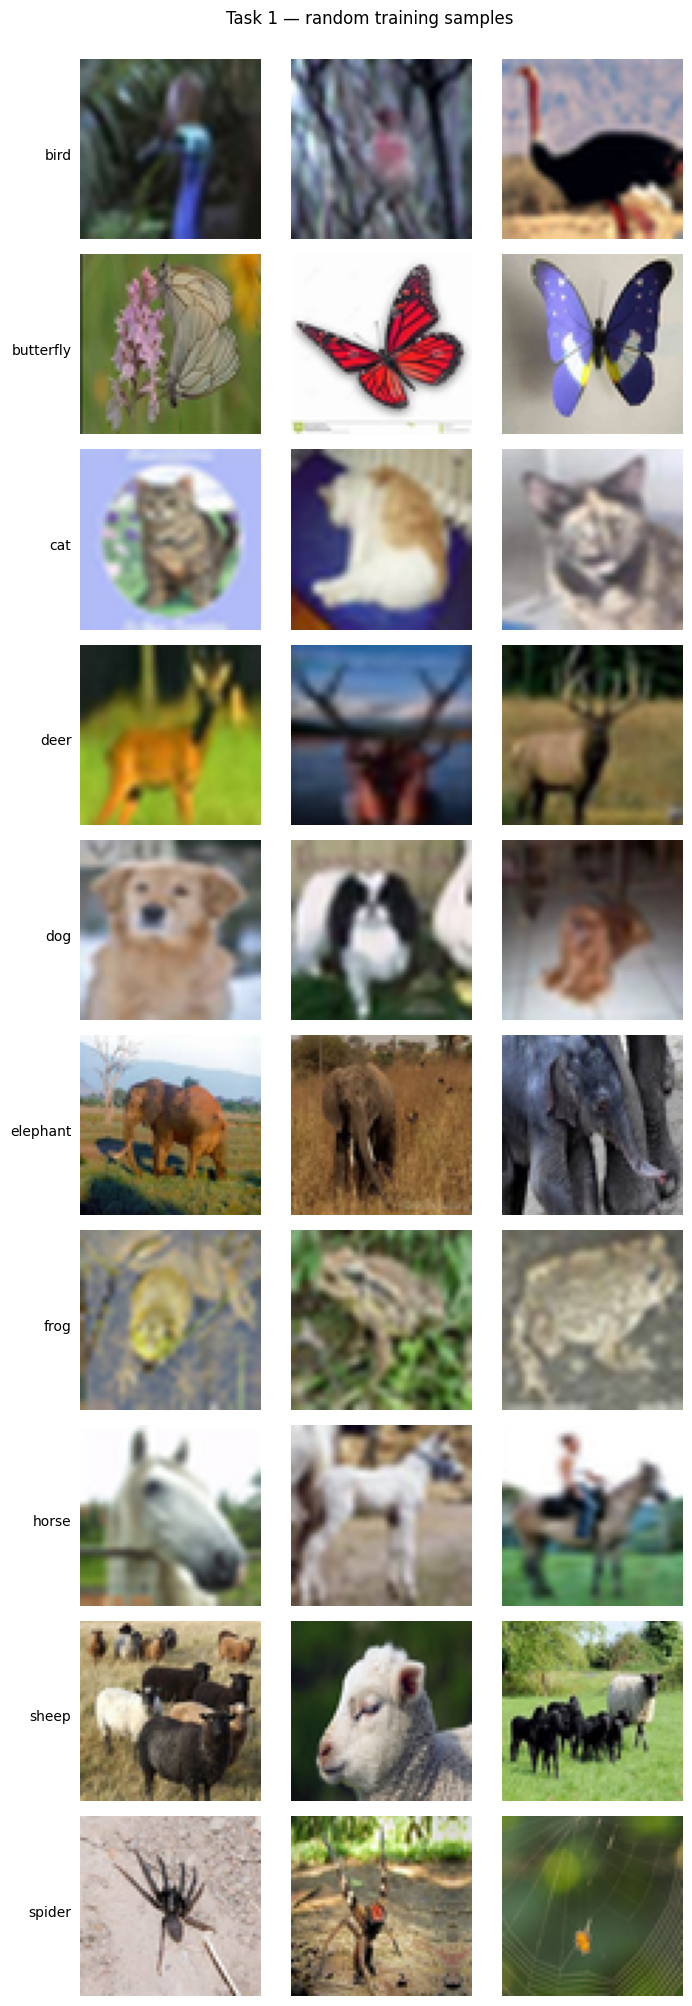

In [7]:
# Show 3 random training samples per class — Task 1
np.random.seed(42)
fig, axes = plt.subplots(10, 3, figsize=(7, 20))
for cid in range(10):
    idxs = np.where(y1 == cid)[0]
    chosen = np.random.choice(idxs, size=3, replace=False)
    for j, k in enumerate(chosen):
        img_path = TASK1_DIR + "/" + train_meta_t1.iloc[k]["image_path"]
        img = Image.open(img_path).convert("RGB")
        axes[cid, j].imshow(img)
        axes[cid, j].axis("off")
        if j == 0:
            axes[cid, j].set_title(class_names_t1[cid], loc="left", fontsize=10,
                                    x=-0.05, y=0.4, rotation=0, ha="right")
fig.suptitle("Task 1 — random training samples", y=1.001)
fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_task1_samples.png", dpi=120, bbox_inches="tight")
plt.show()

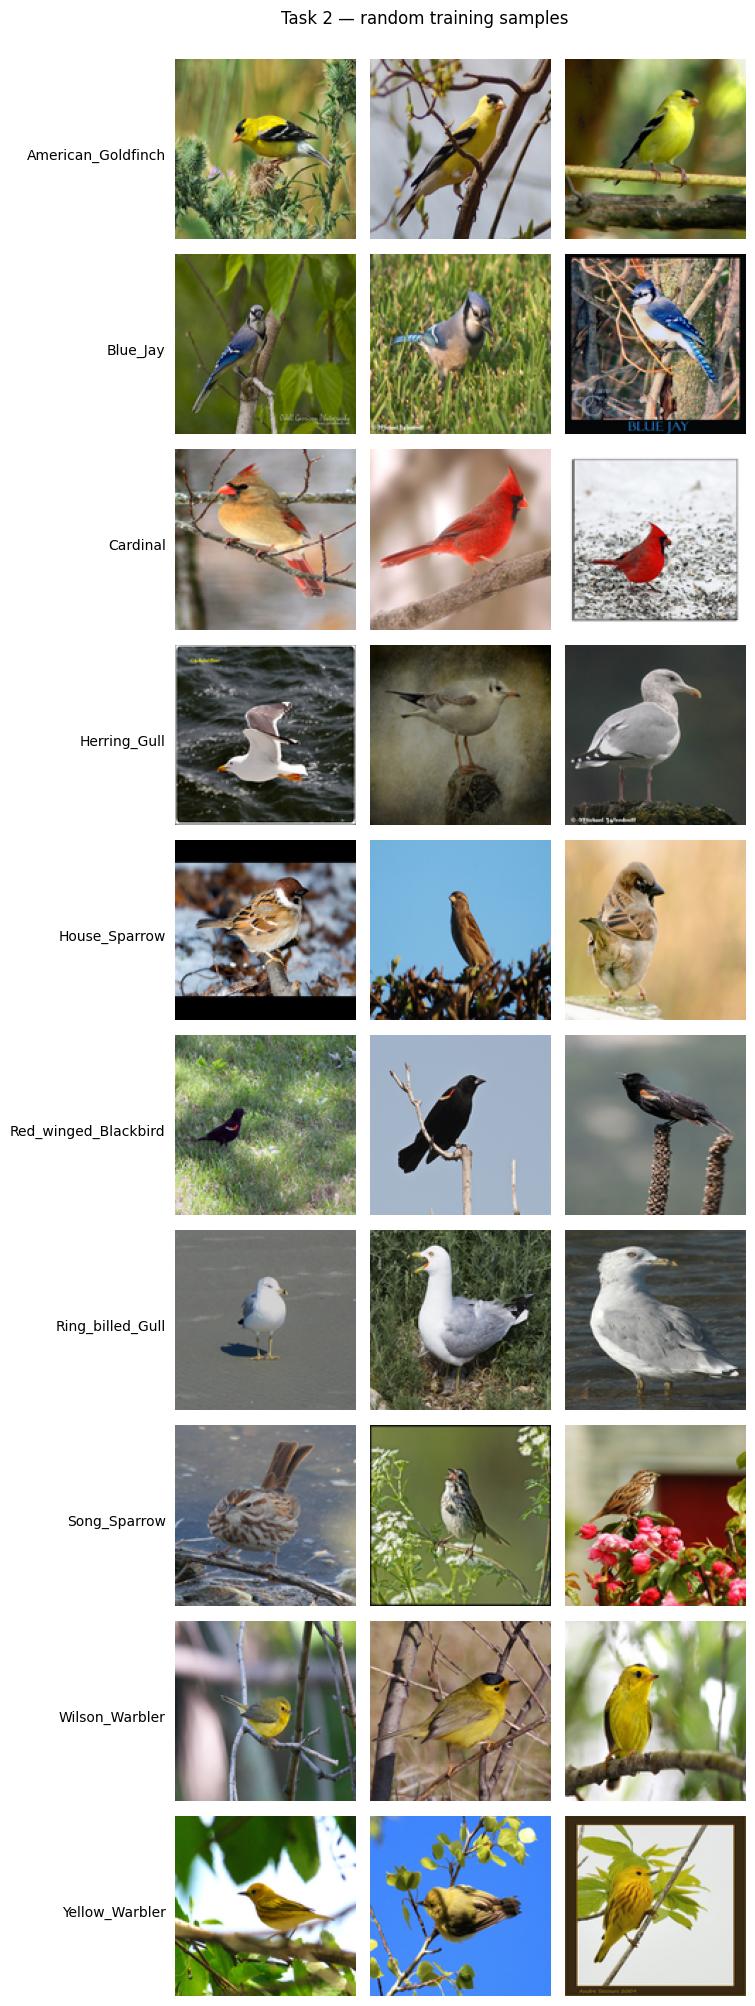

In [8]:
# Same for Task 2
np.random.seed(42)
fig, axes = plt.subplots(10, 3, figsize=(7, 20))
for cid in range(10):
    idxs = np.where(y2 == cid)[0]
    chosen = np.random.choice(idxs, size=3, replace=False)
    for j, k in enumerate(chosen):
        img_path = TASK2_DIR + "/" + train_meta_t2.iloc[k]["image_path"]
        img = Image.open(img_path).convert("RGB")
        axes[cid, j].imshow(img)
        axes[cid, j].axis("off")
        if j == 0:
            axes[cid, j].set_title(class_names_t2[cid], loc="left", fontsize=10,
                                    x=-0.05, y=0.4, rotation=0, ha="right")
fig.suptitle("Task 2 — random training samples", y=1.001)
fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_task2_samples.png", dpi=120, bbox_inches="tight")
plt.show()

### 1.3 Feature statistics

Check the range of each feature block. `extra` has a huge range (~28785), so LR/SVM will need `StandardScaler`. RF doesn't care (tree splits are scale invariant — Lecture 13).

In [9]:
print("Task 1 feature stats:")
for name, arr in [("color_hist", X1_color), ("hog_pca", X1_hog), ("extra", X1_extra)]:
    print(f"  {name:11s} shape={arr.shape}  min={arr.min():.3f}  max={arr.max():.3f}  mean={arr.mean():.3f}  std={arr.std():.3f}")

print("\nTask 2 feature stats:")
for name, arr in [("color_hist", X2_color), ("hog_pca", X2_hog), ("extra", X2_extra)]:
    print(f"  {name:11s} shape={arr.shape}  min={arr.min():.3f}  max={arr.max():.3f}  mean={arr.mean():.3f}  std={arr.std():.3f}")

stats_text = "Feature block statistics (training set) — see notebook output above."
with open(RES_DIR + "/eda_feature_stats.txt", "w", encoding="utf-8") as f:
    f.write(stats_text)

Task 1 feature stats:
  color_hist  shape=(3750, 96)  min=0.000  max=0.992  mean=0.031  std=0.043
  hog_pca     shape=(3750, 100)  min=-1.373  max=1.811  mean=0.000  std=0.138
  extra       shape=(3750, 23)  min=0.000  max=28785.488  mean=64.452  std=537.739

Task 2 feature stats:
  color_hist  shape=(417, 96)  min=0.000  max=0.867  mean=0.031  std=0.051
  hog_pca     shape=(417, 100)  min=-3.432  max=3.683  mean=-0.000  std=0.354
  extra       shape=(417, 23)  min=0.005  max=10558.185  mean=83.814  std=503.947


## Phase 2 — Baseline

3 models (LogisticRegression, LinearSVC, RandomForest) x 4 feature combos x 2 tasks = 24 CV experiments. LR/SVC use StandardScaler; RF uses raw features.

In [10]:
# Concatenate all 3 feature blocks for the "all" config
X1_all = np.concatenate([X1_color, X1_hog, X1_extra], axis=1)
X2_all = np.concatenate([X2_color, X2_hog, X2_extra], axis=1)

X1_all_test = np.concatenate([X1_color_test, X1_hog_test, X1_extra_test], axis=1)
X2_all_test = np.concatenate([X2_color_test, X2_hog_test, X2_extra_test], axis=1)

print("X1_all shape:", X1_all.shape)
print("X2_all shape:", X2_all.shape)

X1_all shape: (3750, 219)
X2_all shape: (417, 219)


In [11]:
# Pre-compute standardised versions of the concatenated features for t-SNE later.
# (For the CV experiments in the next cell we will use Pipeline, which fits
# StandardScaler PER FOLD — the correct way to combine scaling with CV.)
from sklearn.preprocessing import StandardScaler

X1_all_s = StandardScaler().fit_transform(X1_all)
X2_all_s = StandardScaler().fit_transform(X2_all)
print("Standardised X1_all and X2_all for t-SNE plotting in Phase 3.")

Standardised X1_all and X2_all for t-SNE plotting in Phase 3.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# 5-fold stratified CV (shuffle because data is sorted by class)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Wrap StandardScaler + classifier in a Pipeline so the scaler is fit
# only on each fold's training data — this is the methodologically correct
# way to combine feature scaling with CV (no leakage from validation fold).
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=2000, random_state=42))])
svc_pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', LinearSVC(max_iter=5000, random_state=42))])
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
# RF doesn't need scaling — tree splits are scale-invariant (Lecture 13).

linear_models = [lr_pipe, svc_pipe]
linear_titles = ['LogReg', 'LinearSVC']

results = []

# === Task 1 ===
print("=== Task 1 ===")
features_t1 = [('color_hist', X1_color), ('hog_pca', X1_hog),
               ('extra', X1_extra), ('all_concat', X1_all)]
for fname, X in features_t1:
    for title, model in zip(linear_titles, linear_models):
        scores = cross_val_score(model, X, y1, cv=cv)
        results.append({'task': 1, 'features': fname, 'model': title,
                        'accuracy_mean': scores.mean(), 'accuracy_std': scores.std()})
        print(f"  {fname:11s} {title:11s} acc = {scores.mean():.3f}")
    scores = cross_val_score(rf_model, X, y1, cv=cv)
    results.append({'task': 1, 'features': fname, 'model': 'RandomForest',
                    'accuracy_mean': scores.mean(), 'accuracy_std': scores.std()})
    print(f"  {fname:11s} RandomForest acc = {scores.mean():.3f}")

# === Task 2 ===
print("\n=== Task 2 ===")
features_t2 = [('color_hist', X2_color), ('hog_pca', X2_hog),
               ('extra', X2_extra), ('all_concat', X2_all)]
for fname, X in features_t2:
    for title, model in zip(linear_titles, linear_models):
        scores = cross_val_score(model, X, y2, cv=cv)
        results.append({'task': 2, 'features': fname, 'model': title,
                        'accuracy_mean': scores.mean(), 'accuracy_std': scores.std()})
        print(f"  {fname:11s} {title:11s} acc = {scores.mean():.3f}")
    scores = cross_val_score(rf_model, X, y2, cv=cv)
    results.append({'task': 2, 'features': fname, 'model': 'RandomForest',
                    'accuracy_mean': scores.mean(), 'accuracy_std': scores.std()})
    print(f"  {fname:11s} RandomForest acc = {scores.mean():.3f}")

baseline_all = pd.DataFrame(results)
baseline_all.to_csv(RES_DIR + "/baseline_cv_results.csv", index=False)
baseline_all

=== Task 1 ===


  color_hist  LogReg      acc = 0.205


  color_hist  LinearSVC   acc = 0.206


  color_hist  RandomForest acc = 0.318


  hog_pca     LogReg      acc = 0.433


...

  hog_pca     RandomForest acc = 0.209
  extra       LogReg      acc = 0.273
  extra       LinearSVC   acc = 0.292


  extra       RandomForest acc = 0.211
  all_concat  LogReg      acc = 0.221


  all_concat  LinearSVC   acc = 0.197


  all_concat  RandomForest acc = 0.341


,task,features,model,accuracy_mean,accuracy_std
0,1,color_hist,LogReg,0.205067,0.007025
1,1,color_hist,LinearSVC,0.206400,0.010713
2,1,color_hist,RandomForest,0.318133,0.014645
3,1,hog_pca,LogReg,0.433067,0.023618
4,1,hog_pca,LinearSVC,0.429600,0.020953
5,1,hog_pca,RandomForest,0.410667,0.020587
6,1,extra,LogReg,0.465067,0.007322
7,1,extra,LinearSVC,0.448533,0.006174
8,1,extra,RandomForest,0.431467,0.015991
9,1,all_concat,LogReg,0.533600,0.014444


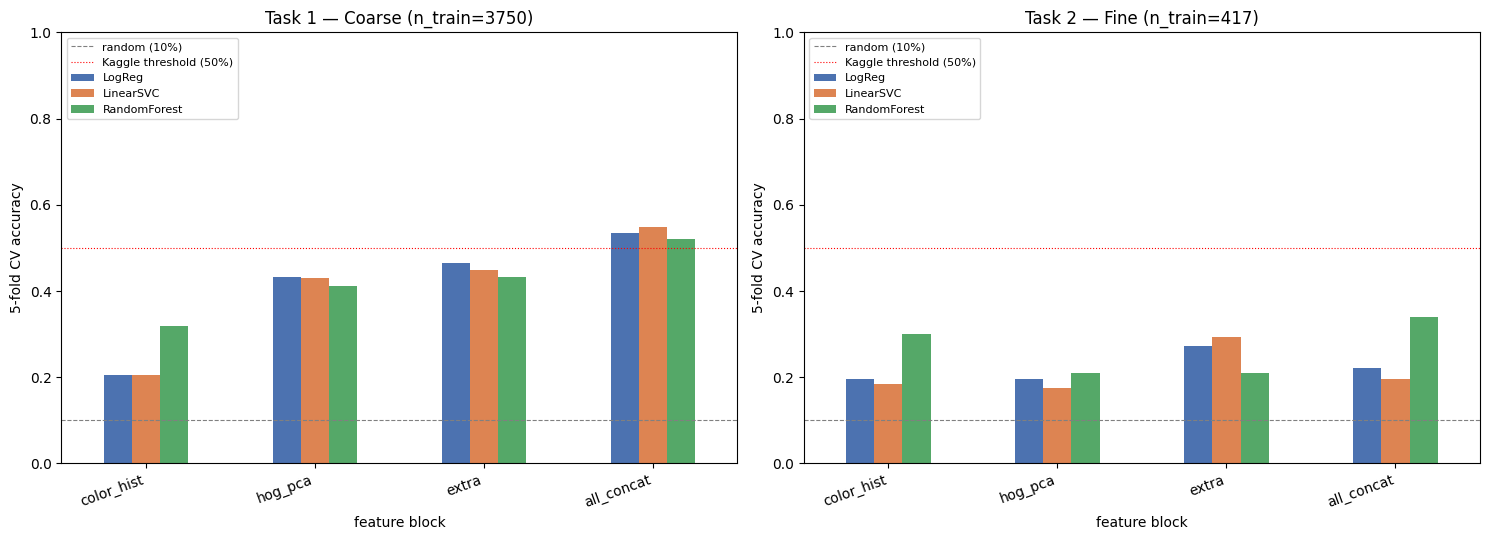

In [13]:
# Plot the comparison: 3 models * 4 feature configs for each task
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, tid, title in [(axes[0], 1, "Task 1 — Coarse (n_train=3750)"),
                        (axes[1], 2, "Task 2 — Fine (n_train=417)")]:
    sub = baseline_all[baseline_all['task'] == tid]
    pivot = sub.pivot(index='features', columns='model', values='accuracy_mean')
    pivot = pivot[['LogReg', 'LinearSVC', 'RandomForest']]
    pivot = pivot.reindex(['color_hist', 'hog_pca', 'extra', 'all_concat'])
    pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(title)
    ax.set_xlabel('feature block')
    ax.set_ylabel('5-fold CV accuracy')
    ax.set_ylim(0, 1)
    ax.axhline(0.10, ls='--', color='gray', lw=0.8, label='random (10%)')
    ax.axhline(0.50, ls=':',  color='red',  lw=0.8, label='Kaggle threshold (50%)')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_xticklabels(pivot.index, rotation=20, ha='right')

fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 3 — CNN feature extraction (ResNet50)

ResNet50 pre-trained on ImageNet, used as a frozen feature extractor (final classification layer removed). Each image becomes a 2048-d embedding.

In [14]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from tqdm.auto import tqdm

# Load pre-trained ResNet50 (ImageNet weights)
print("Loading ResNet50 with ImageNet weights...")
backbone = tv_models.resnet50(weights="IMAGENET1K_V2")
backbone.fc = nn.Identity()    # Remove the 1000-class head -> output becomes 2048-d
backbone.eval()                # Eval mode (no dropout, etc.)

# Don't compute gradients (we're not training)
for p in backbone.parameters():
    p.requires_grad_(False)

# Standard ImageNet preprocessing
preprocess = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("ResNet50 ready. Output dim = 2048.")

Loading ResNet50 with ImageNet weights...


ResNet50 ready. Output dim = 2048.


In [15]:
# Function to extract embeddings for a list of image paths
def extract_embeddings(image_paths, model, transform, batch_size=32):
    chunks = []
    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch_paths = image_paths[i:i+batch_size]
        imgs = torch.stack([transform(Image.open(p).convert("RGB")) for p in batch_paths])
        with torch.no_grad():
            feats = model(imgs)
        chunks.append(feats.numpy().astype(np.float32))
    return np.concatenate(chunks, axis=0)

# Build the full image paths
train_paths_t1 = [TASK1_DIR + "/" + p for p in train_meta_t1["image_path"]]
test_paths_t1  = [TASK1_DIR + "/" + p for p in test_meta_t1["image_path"]]
train_paths_t2 = [TASK2_DIR + "/" + p for p in train_meta_t2["image_path"]]
test_paths_t2  = [TASK2_DIR + "/" + p for p in test_meta_t2["image_path"]]

In [16]:
# Extract or load from cache: 4 sets total
# Task 1 train
cache_path = CACHE_DIR + "/task1_resnet50_train.npy"
if os.path.exists(cache_path):
    emb_t1_train = np.load(cache_path)
    print(f"Cache hit: task1_resnet50_train.npy  shape={emb_t1_train.shape}")
else:
    print("Extracting Task 1 train embeddings...")
    emb_t1_train = extract_embeddings(train_paths_t1, backbone, preprocess)
    np.save(cache_path, emb_t1_train)

# Task 1 test
cache_path = CACHE_DIR + "/task1_resnet50_test.npy"
if os.path.exists(cache_path):
    emb_t1_test = np.load(cache_path)
    print(f"Cache hit: task1_resnet50_test.npy  shape={emb_t1_test.shape}")
else:
    print("Extracting Task 1 test embeddings...")
    emb_t1_test = extract_embeddings(test_paths_t1, backbone, preprocess)
    np.save(cache_path, emb_t1_test)

# Task 2 train
cache_path = CACHE_DIR + "/task2_resnet50_train.npy"
if os.path.exists(cache_path):
    emb_t2_train = np.load(cache_path)
    print(f"Cache hit: task2_resnet50_train.npy  shape={emb_t2_train.shape}")
else:
    print("Extracting Task 2 train embeddings...")
    emb_t2_train = extract_embeddings(train_paths_t2, backbone, preprocess)
    np.save(cache_path, emb_t2_train)

# Task 2 test
cache_path = CACHE_DIR + "/task2_resnet50_test.npy"
if os.path.exists(cache_path):
    emb_t2_test = np.load(cache_path)
    print(f"Cache hit: task2_resnet50_test.npy  shape={emb_t2_test.shape}")
else:
    print("Extracting Task 2 test embeddings...")
    emb_t2_test = extract_embeddings(test_paths_t2, backbone, preprocess)
    np.save(cache_path, emb_t2_test)

print("\nAll embeddings ready:")
print(f"  task1 train: {emb_t1_train.shape}")
print(f"  task1 test:  {emb_t1_test.shape}")
print(f"  task2 train: {emb_t2_train.shape}")
print(f"  task2 test:  {emb_t2_test.shape}")

Cache hit: task1_resnet50_train.npy  shape=(3750, 2048)
Cache hit: task1_resnet50_test.npy  shape=(1250, 2048)
Cache hit: task2_resnet50_train.npy  shape=(417, 2048)
Cache hit: task2_resnet50_test.npy  shape=(180, 2048)

All embeddings ready:
  task1 train: (3750, 2048)
  task1 test:  (1250, 2048)
  task2 train: (417, 2048)
  task2 test:  (180, 2048)


### 3.1 t-SNE: do CNN embeddings separate the classes better than traditional features?

t-SNE projects high-dim vectors to 2-D while preserving local neighborhood structure. If classes form tight clusters on the t-SNE plot, the feature space is good for classification.

We compare 4 panels: (Task 1 / Task 2) × (traditional features / ResNet50 embedding). The CNN side should show much better clustering, especially on Task 2.

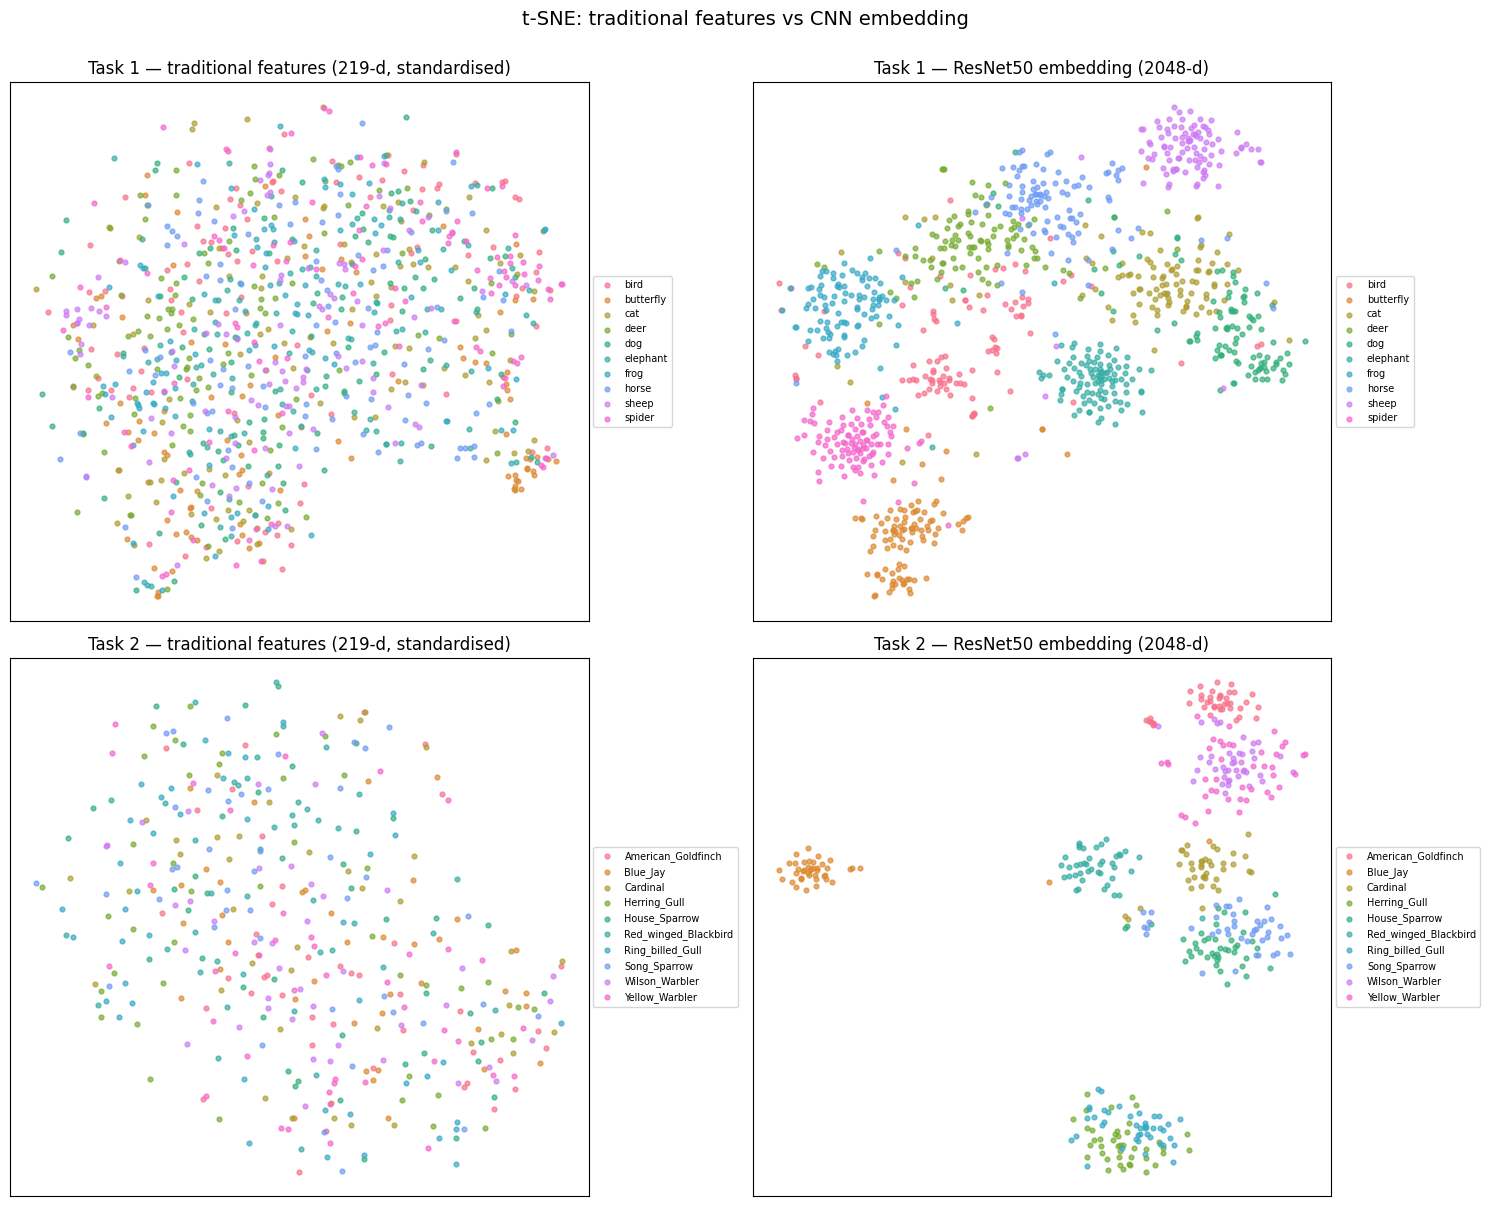

In [17]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
colors = sns.color_palette("husl", 10)

# Subsample Task 1 (3750 too slow for t-SNE)
np.random.seed(42)
sub_idx_t1 = np.concatenate([np.random.choice(np.where(y1 == c)[0], size=100, replace=False) for c in range(10)])
y1_sub = y1[sub_idx_t1]

# --- Task 1 traditional ---
Z = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(X1_all_s[sub_idx_t1])
for cid in range(10):
    mask = y1_sub == cid
    axes[0, 0].scatter(Z[mask, 0], Z[mask, 1], s=12, alpha=0.7, color=colors[cid], label=class_names_t1[cid])
axes[0, 0].set_title("Task 1 — traditional features (219-d, standardised)")
axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[0, 0].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)

# --- Task 1 CNN ---
Z = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(emb_t1_train[sub_idx_t1])
for cid in range(10):
    mask = y1_sub == cid
    axes[0, 1].scatter(Z[mask, 0], Z[mask, 1], s=12, alpha=0.7, color=colors[cid], label=class_names_t1[cid])
axes[0, 1].set_title("Task 1 — ResNet50 embedding (2048-d)")
axes[0, 1].set_xticks([]); axes[0, 1].set_yticks([])
axes[0, 1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)

# --- Task 2 traditional ---
Z = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(X2_all_s)
for cid in range(10):
    mask = y2 == cid
    axes[1, 0].scatter(Z[mask, 0], Z[mask, 1], s=12, alpha=0.7, color=colors[cid], label=class_names_t2[cid])
axes[1, 0].set_title("Task 2 — traditional features (219-d, standardised)")
axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
axes[1, 0].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)

# --- Task 2 CNN ---
Z = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(emb_t2_train)
for cid in range(10):
    mask = y2 == cid
    axes[1, 1].scatter(Z[mask, 0], Z[mask, 1], s=12, alpha=0.7, color=colors[cid], label=class_names_t2[cid])
axes[1, 1].set_title("Task 2 — ResNet50 embedding (2048-d)")
axes[1, 1].set_xticks([]); axes[1, 1].set_yticks([])
axes[1, 1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)

fig.suptitle("t-SNE: traditional features vs CNN embedding", y=1.001, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 4 — Final models on CNN embeddings

Three distinct models (Logistic Regression, RBF-SVM, Random Forest) on two feature configurations (`cnn_only` and `cnn_plus_trad`). 5-fold CV with `cross_val_predict` to get OOF predictions for Phase 5.

In [18]:
# Build the feature matrices for Phase 4
X1_cnn = emb_t1_train     # (3750, 2048)
X2_cnn = emb_t2_train     # (417, 2048)

X1_cnn_plus_trad = np.concatenate([emb_t1_train, X1_color, X1_hog, X1_extra], axis=1)  # (3750, 2267)
X2_cnn_plus_trad = np.concatenate([emb_t2_train, X2_color, X2_hog, X2_extra], axis=1)  # (417, 2267)

# Test versions for Phase 6 (final submission)
X1_cnn_test_arr = emb_t1_test
X2_cnn_test_arr = emb_t2_test
X1_cnn_plus_trad_test = np.concatenate([emb_t1_test, X1_color_test, X1_hog_test, X1_extra_test], axis=1)
X2_cnn_plus_trad_test = np.concatenate([emb_t2_test, X2_color_test, X2_hog_test, X2_extra_test], axis=1)

print("Phase 4 features ready:")
print(f"  Task 1 CNN only:    {X1_cnn.shape}")
print(f"  Task 1 CNN + trad:  {X1_cnn_plus_trad.shape}")
print(f"  Task 2 CNN only:    {X2_cnn.shape}")
print(f"  Task 2 CNN + trad:  {X2_cnn_plus_trad.shape}")
# Note: no standalone scaling — the Pipeline in the next cell handles per-fold scaling.

Phase 4 features ready:
  Task 1 CNN only:    (3750, 2048)
  Task 1 CNN + trad:  (3750, 2267)
  Task 2 CNN only:    (417, 2048)
  Task 2 CNN + trad:  (417, 2267)


In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, f1_score
import time

# Pipelines: StandardScaler fit per fold inside CV (no leakage).
lr_pipe_final = Pipeline([('scaler', StandardScaler()),
                          ('clf', LogisticRegression(C=1.0, max_iter=3000, random_state=42))])
svm_pipe_final = Pipeline([('scaler', StandardScaler()),
                           ('clf', SVC(C=10.0, kernel='rbf', gamma='scale', random_state=42))])
rf_model_final = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
# RF uses raw features (scale-invariant).

phase4_results = []

# === Task 1 ===
print("=== Task 1 (3750 samples) — RBF-SVM is slow ===")
configs_t1 = [('cnn_only', X1_cnn), ('cnn_plus_trad', X1_cnn_plus_trad)]
for fname, X in configs_t1:
    # LR
    t0 = time.time()
    preds = cross_val_predict(lr_pipe_final, X, y1, cv=cv)
    np.save(CACHE_DIR + f"/oof_task1_{fname}_LR.npy", preds)
    acc = accuracy_score(y1, preds); f1m = f1_score(y1, preds, average='macro')
    phase4_results.append({'task':1, 'feature_config':fname, 'model':'LR',
                           'accuracy':acc, 'f1_macro':f1m})
    print(f"  {fname:14s} LR       acc={acc:.3f}  f1={f1m:.3f}  ({time.time()-t0:.1f}s)")

    # SVM
    t0 = time.time()
    preds = cross_val_predict(svm_pipe_final, X, y1, cv=cv)
    np.save(CACHE_DIR + f"/oof_task1_{fname}_SVM_RBF.npy", preds)
    acc = accuracy_score(y1, preds); f1m = f1_score(y1, preds, average='macro')
    phase4_results.append({'task':1, 'feature_config':fname, 'model':'SVM_RBF',
                           'accuracy':acc, 'f1_macro':f1m})
    print(f"  {fname:14s} SVM_RBF  acc={acc:.3f}  f1={f1m:.3f}  ({time.time()-t0:.1f}s)")

    # RF (raw, no scaling needed)
    t0 = time.time()
    preds = cross_val_predict(rf_model_final, X, y1, cv=cv)
    np.save(CACHE_DIR + f"/oof_task1_{fname}_RF.npy", preds)
    acc = accuracy_score(y1, preds); f1m = f1_score(y1, preds, average='macro')
    phase4_results.append({'task':1, 'feature_config':fname, 'model':'RF',
                           'accuracy':acc, 'f1_macro':f1m})
    print(f"  {fname:14s} RF       acc={acc:.3f}  f1={f1m:.3f}  ({time.time()-t0:.1f}s)")

# === Task 2 ===
print("\n=== Task 2 (417 samples) ===")
configs_t2 = [('cnn_only', X2_cnn), ('cnn_plus_trad', X2_cnn_plus_trad)]
for fname, X in configs_t2:
    t0 = time.time()
    preds = cross_val_predict(lr_pipe_final, X, y2, cv=cv)
    np.save(CACHE_DIR + f"/oof_task2_{fname}_LR.npy", preds)
    acc = accuracy_score(y2, preds); f1m = f1_score(y2, preds, average='macro')
    phase4_results.append({'task':2, 'feature_config':fname, 'model':'LR',
                           'accuracy':acc, 'f1_macro':f1m})
    print(f"  {fname:14s} LR       acc={acc:.3f}  f1={f1m:.3f}  ({time.time()-t0:.1f}s)")

    t0 = time.time()
    preds = cross_val_predict(svm_pipe_final, X, y2, cv=cv)
    np.save(CACHE_DIR + f"/oof_task2_{fname}_SVM_RBF.npy", preds)
    acc = accuracy_score(y2, preds); f1m = f1_score(y2, preds, average='macro')
    phase4_results.append({'task':2, 'feature_config':fname, 'model':'SVM_RBF',
                           'accuracy':acc, 'f1_macro':f1m})
    print(f"  {fname:14s} SVM_RBF  acc={acc:.3f}  f1={f1m:.3f}  ({time.time()-t0:.1f}s)")

    t0 = time.time()
    preds = cross_val_predict(rf_model_final, X, y2, cv=cv)
    np.save(CACHE_DIR + f"/oof_task2_{fname}_RF.npy", preds)
    acc = accuracy_score(y2, preds); f1m = f1_score(y2, preds, average='macro')
    phase4_results.append({'task':2, 'feature_config':fname, 'model':'RF',
                           'accuracy':acc, 'f1_macro':f1m})
    print(f"  {fname:14s} RF       acc={acc:.3f}  f1={f1m:.3f}  ({time.time()-t0:.1f}s)")

phase4_all = pd.DataFrame(phase4_results)
phase4_all.to_csv(RES_DIR + "/phase4_cv_results.csv", index=False)
phase4_all

=== Task 1 (3750 samples) — RBF-SVM is slow ===


  cnn_only       LR       acc=0.915  f1=0.915  (3.8s)


  cnn_only       SVM_RBF  acc=0.880  f1=0.883  (54.0s)


  cnn_only       RF       acc=0.887  f1=0.887  (35.1s)


  cnn_plus_trad  LR       acc=0.915  f1=0.915  (4.5s)


...

  cnn_only       RF       acc=0.863  f1=0.863  (9.0s)


  cnn_plus_trad  LR       acc=0.854  f1=0.854  (1.6s)


  cnn_plus_trad  SVM_RBF  acc=0.770  f1=0.775  (1.1s)


  cnn_plus_trad  RF       acc=0.863  f1=0.863  (9.5s)


,task,feature_config,model,accuracy,f1_macro
0,1,cnn_only,LR,0.915200,0.915302
1,1,cnn_only,SVM_RBF,0.879733,0.883148
2,1,cnn_only,RF,0.887200,0.886858
3,1,cnn_plus_trad,LR,0.915200,0.915353
4,1,cnn_plus_trad,SVM_RBF,0.879733,0.882857
5,1,cnn_plus_trad,RF,0.893600,0.893207
6,2,cnn_only,LR,0.844125,0.843818
7,2,cnn_only,SVM_RBF,0.774580,0.781268
8,2,cnn_only,RF,0.863309,0.863119
9,2,cnn_plus_trad,LR,0.853717,0.853587


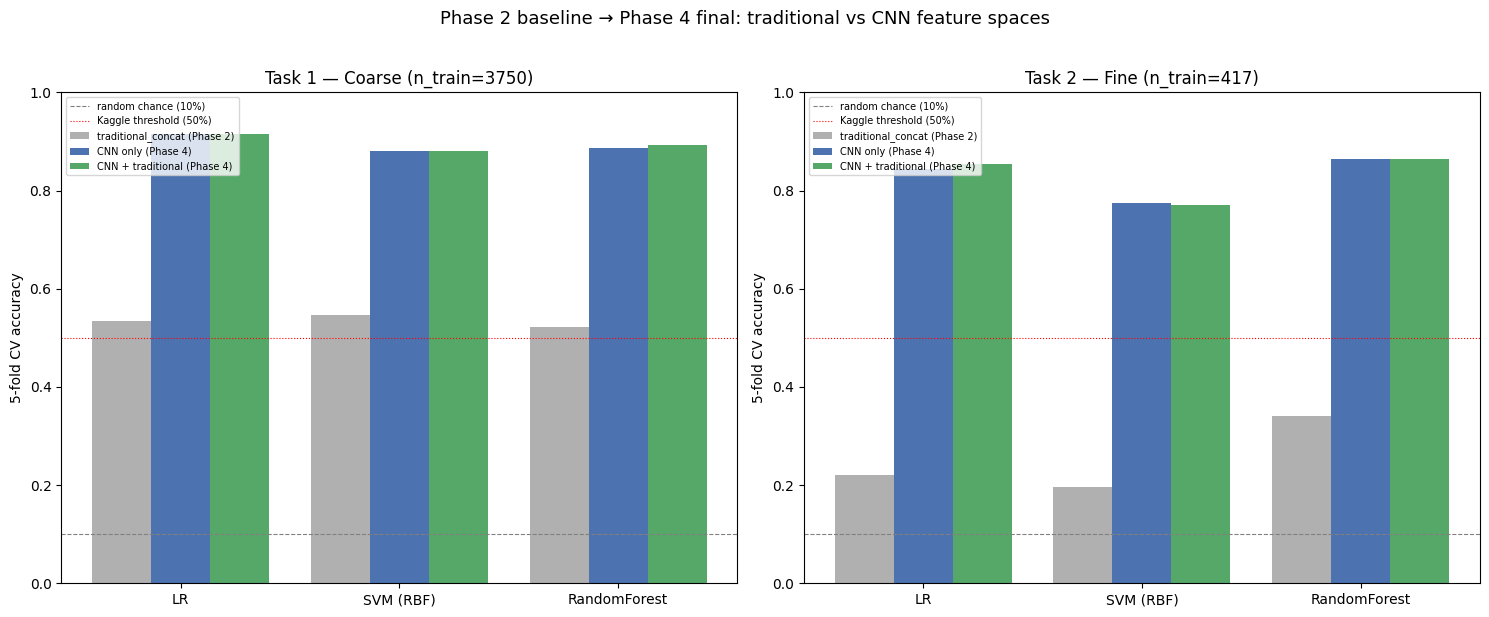

In [20]:
# Compare Phase 2 baseline vs Phase 4 CNN-based models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

p2_model_map = {'LogReg':'LR', 'LinearSVC':'SVM_RBF', 'RandomForest':'RF'}

for ax, tid, title in [(axes[0], 1, "Task 1 — Coarse (n_train=3750)"),
                        (axes[1], 2, "Task 2 — Fine (n_train=417)")]:
    # Phase 2 baseline (all_concat per model)
    p2_LR  = baseline_all[(baseline_all['task']==tid)&(baseline_all['features']=='all_concat')&(baseline_all['model']=='LogReg')]['accuracy_mean'].values[0]
    p2_SVM = baseline_all[(baseline_all['task']==tid)&(baseline_all['features']=='all_concat')&(baseline_all['model']=='LinearSVC')]['accuracy_mean'].values[0]
    p2_RF  = baseline_all[(baseline_all['task']==tid)&(baseline_all['features']=='all_concat')&(baseline_all['model']=='RandomForest')]['accuracy_mean'].values[0]
    p2_vals = [p2_LR, p2_SVM, p2_RF]

    # Phase 4 cnn_only
    p4_only = phase4_all[(phase4_all['task']==tid)&(phase4_all['feature_config']=='cnn_only')]
    p4_only_vals = [p4_only[p4_only['model']==m]['accuracy'].values[0] for m in ['LR','SVM_RBF','RF']]

    # Phase 4 cnn_plus_trad
    p4_plus = phase4_all[(phase4_all['task']==tid)&(phase4_all['feature_config']=='cnn_plus_trad')]
    p4_plus_vals = [p4_plus[p4_plus['model']==m]['accuracy'].values[0] for m in ['LR','SVM_RBF','RF']]

    x = np.arange(3)
    w = 0.27
    ax.bar(x - w, p2_vals,      width=w, label='traditional_concat (Phase 2)', color='#B0B0B0')
    ax.bar(x,     p4_only_vals, width=w, label='CNN only (Phase 4)',           color='#4C72B0')
    ax.bar(x + w, p4_plus_vals, width=w, label='CNN + traditional (Phase 4)',  color='#55A868')

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'SVM (RBF)', 'RandomForest'])
    ax.set_ylabel("5-fold CV accuracy")
    ax.set_ylim(0, 1)
    ax.axhline(0.10, ls='--', color='gray', lw=0.8, label='random chance (10%)')
    ax.axhline(0.50, ls=':',  color='red',  lw=0.8, label='Kaggle threshold (50%)')
    ax.legend(loc='upper left', fontsize=7)

fig.suptitle("Phase 2 baseline → Phase 4 final: traditional vs CNN feature spaces", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_phase4_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 4.5 — Hyperparameter tuning (Task 2 Random Forest)

Small GridSearchCV on the best Task 2 model.

In [21]:
from sklearn.model_selection import GridSearchCV

# Small grid — keep total fits tractable on CPU
rf_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt'],
}

# 5-fold stratified CV, optimise macro-F1 (matches what we report in Phase 4)
rf_tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=rf_tuning_cv,
    n_jobs=-1,
    verbose=1,
)

print("Fitting GridSearchCV on Task 2 with CNN+traditional features...")
t0 = time.time()
rf_grid.fit(X2_cnn_plus_trad, y2)
print(f"Done in {time.time()-t0:.1f}s")
print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV macro-F1: {rf_grid.best_score_:.4f}")

Fitting GridSearchCV on Task 2 with CNN+traditional features...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Done in 81.5s

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV macro-F1: 0.8653


In [22]:
# Compare tuned vs default RF on Task 2
default_rf_score = phase4_all[(phase4_all['task']==2) &
                              (phase4_all['feature_config']=='cnn_plus_trad') &
                              (phase4_all['model']=='RF')]['f1_macro'].values[0]
tuned_rf_score = rf_grid.best_score_

print(f"Task 2 RF + cnn+trad:")
print(f"  Default params:  f1_macro = {default_rf_score:.4f}")
print(f"  Tuned params:    f1_macro = {tuned_rf_score:.4f}")
print(f"  Improvement:     {(tuned_rf_score - default_rf_score)*100:+.2f} pp")
print(f"\nBest hyper-parameters found:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k:18s} = {v}")

# Save the best params for the report
import json
with open(RES_DIR + "/rf_best_params.json", "w") as f:
    json.dump({
        'task': 2,
        'feature_config': 'cnn_plus_trad',
        'best_params': rf_grid.best_params_,
        'best_cv_f1_macro': float(rf_grid.best_score_),
        'default_cv_f1_macro': float(default_rf_score),
    }, f, indent=2)
print(f"\nSaved {RES_DIR}/rf_best_params.json")

Task 2 RF + cnn+trad:
  Default params:  f1_macro = 0.8628
  Tuned params:    f1_macro = 0.8653
  Improvement:     +0.25 pp

Best hyper-parameters found:
  max_depth          = None
  max_features       = sqrt
  min_samples_leaf   = 3
  n_estimators       = 200

Saved D:/2026S1/COMP30027/Assignment2/outputs/results/rf_best_params.json


## Phase 5 — Error analysis

Uses the OOF predictions saved in Phase 4 — no extra CV needed.

In [23]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Best models from Phase 4: Task 1 = LR cnn_only, Task 2 = RF cnn+trad
oof1 = np.load(CACHE_DIR + "/oof_task1_cnn_only_LR.npy")
oof2 = np.load(CACHE_DIR + "/oof_task2_cnn_plus_trad_RF.npy")

print(f"Task 1 OOF preds shape={oof1.shape}, accuracy={(oof1 == y1).mean():.3f}")
print(f"Task 2 OOF preds shape={oof2.shape}, accuracy={(oof2 == y2).mean():.3f}")

Task 1 OOF preds shape=(3750,), accuracy=0.915
Task 2 OOF preds shape=(417,), accuracy=0.863


### 5.1 Confusion matrices

Rows = true class, columns = predicted class. Cells coloured by row-normalised proportion (so each row sums to 1), numbers show the absolute count.

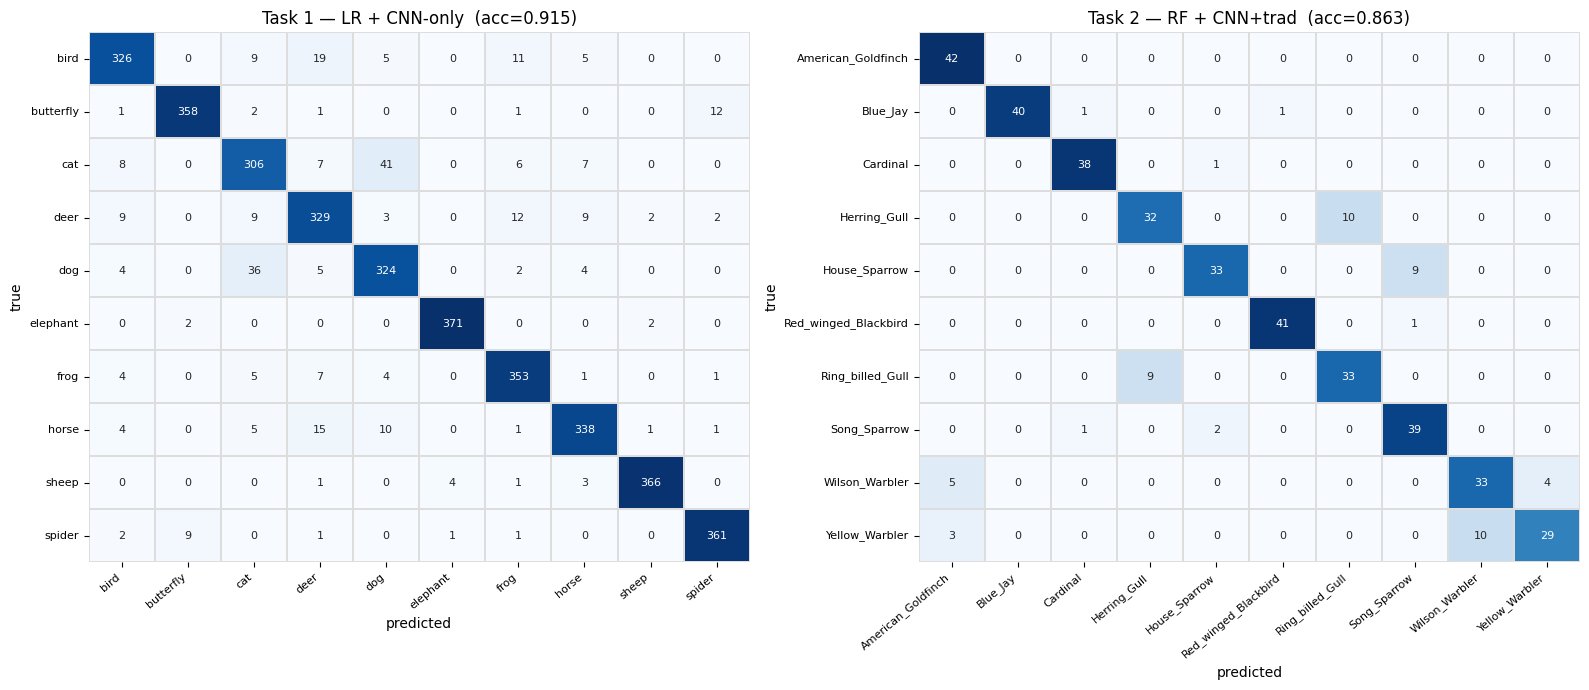

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Task 1
cm1 = confusion_matrix(y1, oof1, labels=range(10))
cm1_norm = cm1 / cm1.sum(axis=1, keepdims=True)
sns.heatmap(cm1_norm, annot=cm1, fmt="d", cmap="Blues",
            xticklabels=class_names_t1, yticklabels=class_names_t1,
            cbar=False, ax=axes[0], annot_kws={"size": 8},
            linewidths=0.3, linecolor="#dddddd")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")
axes[0].set_title(f"Task 1 — LR + CNN-only  (acc={(oof1 == y1).mean():.3f})")
axes[0].set_xticklabels(class_names_t1, rotation=40, ha="right", fontsize=8)
axes[0].set_yticklabels(class_names_t1, rotation=0, fontsize=8)

# Task 2
cm2 = confusion_matrix(y2, oof2, labels=range(10))
cm2_norm = cm2 / cm2.sum(axis=1, keepdims=True)
sns.heatmap(cm2_norm, annot=cm2, fmt="d", cmap="Blues",
            xticklabels=class_names_t2, yticklabels=class_names_t2,
            cbar=False, ax=axes[1], annot_kws={"size": 8},
            linewidths=0.3, linecolor="#dddddd")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("true")
axes[1].set_title(f"Task 2 — RF + CNN+trad  (acc={(oof2 == y2).mean():.3f})")
axes[1].set_xticklabels(class_names_t2, rotation=40, ha="right", fontsize=8)
axes[1].set_yticklabels(class_names_t2, rotation=0, fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Per-class precision/recall/F1

Macro-F1 averaged 0.915 (Task 1) and 0.863 (Task 2). The bar charts below reveal which classes drag the average down.

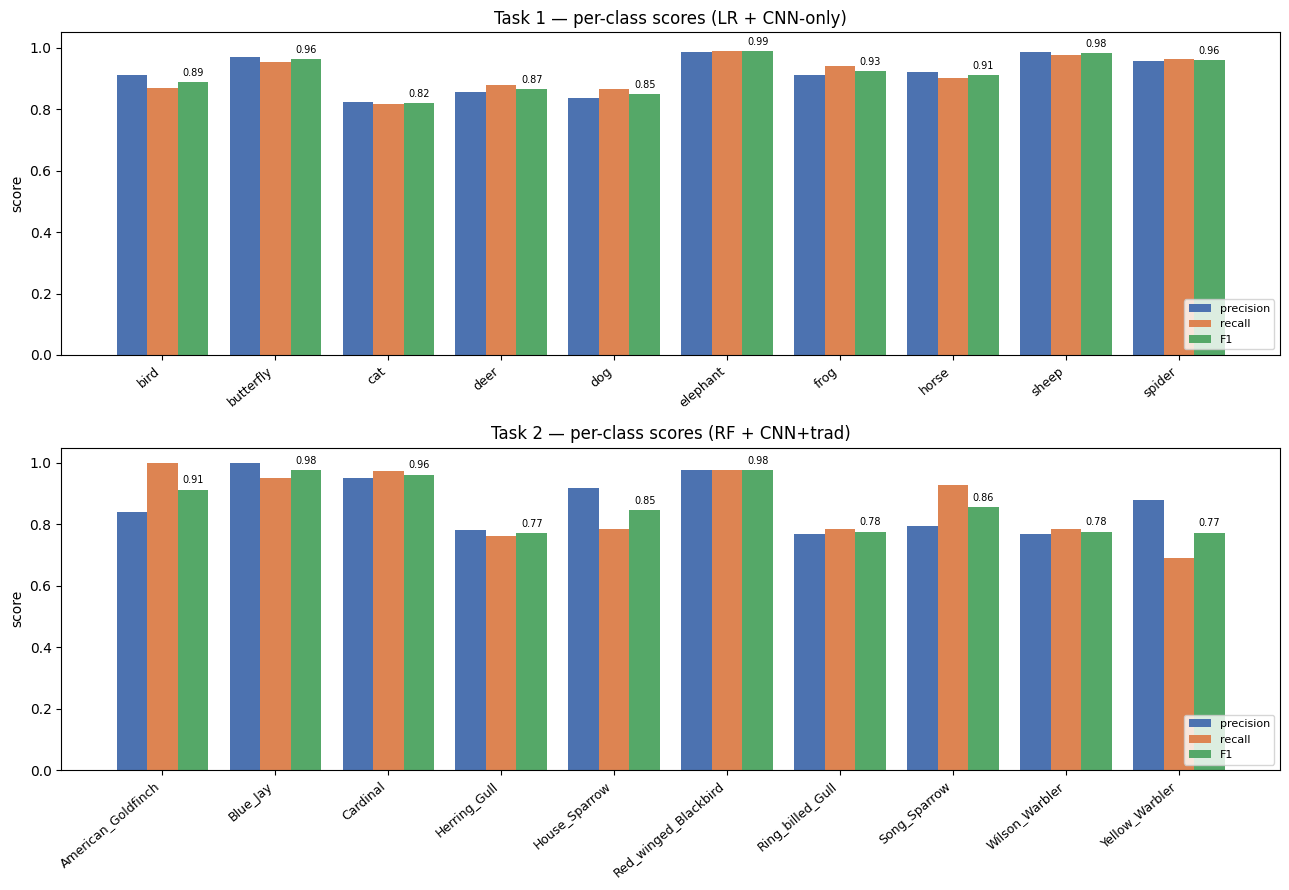

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Task 1
p, r, f, _ = precision_recall_fscore_support(y1, oof1, labels=range(10), zero_division=0)
x = np.arange(10)
w = 0.27
axes[0].bar(x - w, p, width=w, label='precision', color='#4C72B0')
axes[0].bar(x,     r, width=w, label='recall',    color='#DD8452')
axes[0].bar(x + w, f, width=w, label='F1',        color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names_t1, rotation=40, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('score')
axes[0].set_title("Task 1 — per-class scores (LR + CNN-only)")
axes[0].legend(fontsize=8, loc='lower right')
for i, v in enumerate(f):
    axes[0].text(i + w, v + 0.02, f"{v:.2f}", ha='center', fontsize=7)

# Task 2
p, r, f, _ = precision_recall_fscore_support(y2, oof2, labels=range(10), zero_division=0)
axes[1].bar(x - w, p, width=w, label='precision', color='#4C72B0')
axes[1].bar(x,     r, width=w, label='recall',    color='#DD8452')
axes[1].bar(x + w, f, width=w, label='F1',        color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names_t2, rotation=40, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('score')
axes[1].set_title("Task 2 — per-class scores (RF + CNN+trad)")
axes[1].legend(fontsize=8, loc='lower right')
for i, v in enumerate(f):
    axes[1].text(i + w, v + 0.02, f"{v:.2f}", ha='center', fontsize=7)

fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_per_class_scores.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Top confused class pairs

For each task we rank the off-diagonal cells and print the top 8. For Task 2 we explicitly check whether the four pairs predicted in Phase 1 (from visual inspection) dominate this list.

In [26]:
# Find the most confused class pairs (off-diagonal entries with largest counts)
def top_confused_pairs(y_true, y_pred, class_names, top_k=8):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    rows = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                rows.append({
                    'true':  class_names[i],
                    'pred':  class_names[j],
                    'count': int(cm[i, j]),
                    'row_frac': cm[i, j] / cm[i, :].sum(),
                })
    return pd.DataFrame(rows).sort_values('count', ascending=False).head(top_k).reset_index(drop=True)

print("=== Task 1 — top confused pairs ===")
top_t1 = top_confused_pairs(y1, oof1, class_names_t1)
print(top_t1.to_string(index=False))

print("\n=== Task 2 — top confused pairs ===")
top_t2 = top_confused_pairs(y2, oof2, class_names_t2)
print(top_t2.to_string(index=False))

top_t1.to_csv(RES_DIR + "/top_confused_pairs_task1.csv", index=False)
top_t2.to_csv(RES_DIR + "/top_confused_pairs_task2.csv", index=False)

# Check Phase 1 visual predictions
phase1_predictions = [
    ("Herring_Gull", "Ring_billed_Gull"),
    ("Ring_billed_Gull", "Herring_Gull"),
    ("Wilson_Warbler", "Yellow_Warbler"),
    ("Yellow_Warbler", "Wilson_Warbler"),
    ("American_Goldfinch", "Yellow_Warbler"),
    ("Yellow_Warbler", "American_Goldfinch"),
    ("House_Sparrow", "Song_Sparrow"),
    ("Song_Sparrow", "House_Sparrow"),
]
top_pairs_set = set(zip(top_t2["true"], top_t2["pred"]))
hits = [p for p in phase1_predictions if p in top_pairs_set]
print(f"\nPhase 1 visual prediction check:")
print(f"  {len(hits)}/{len(phase1_predictions)} predicted easy-to-confuse pairs landed in Task 2's top-8 confusion list")
for p in hits:
    print(f"    confirmed: {p[0]} -> {p[1]}")

=== Task 1 — top confused pairs ===
     true   pred  count  row_frac
      cat    dog     41  0.109333
      dog    cat     36  0.096000
     bird   deer     19  0.050667
    horse   deer     15  0.040000
butterfly spider     12  0.032000
     deer   frog     12  0.032000
     bird   frog     11  0.029333
    horse    dog     10  0.026667

=== Task 2 — top confused pairs ===
            true               pred  count  row_frac
    Herring_Gull   Ring_billed_Gull     10  0.238095
  Yellow_Warbler     Wilson_Warbler     10  0.238095
   House_Sparrow       Song_Sparrow      9  0.214286
Ring_billed_Gull       Herring_Gull      9  0.214286
  Wilson_Warbler American_Goldfinch      5  0.119048
  Wilson_Warbler     Yellow_Warbler      4  0.095238
  Yellow_Warbler American_Goldfinch      3  0.071429
    Song_Sparrow      House_Sparrow      2  0.047619

Phase 1 visual prediction check:
  7/8 predicted easy-to-confuse pairs landed in Task 2's top-8 confusion list
    confirmed: Herring_Gull -> R

### 5.4 What do the mistakes actually look like?

For Task 2's worst 4 confusion pairs we show 3 misclassified examples each. The image is the bird the human-curated label says it is; the caption says what our model thought it was.

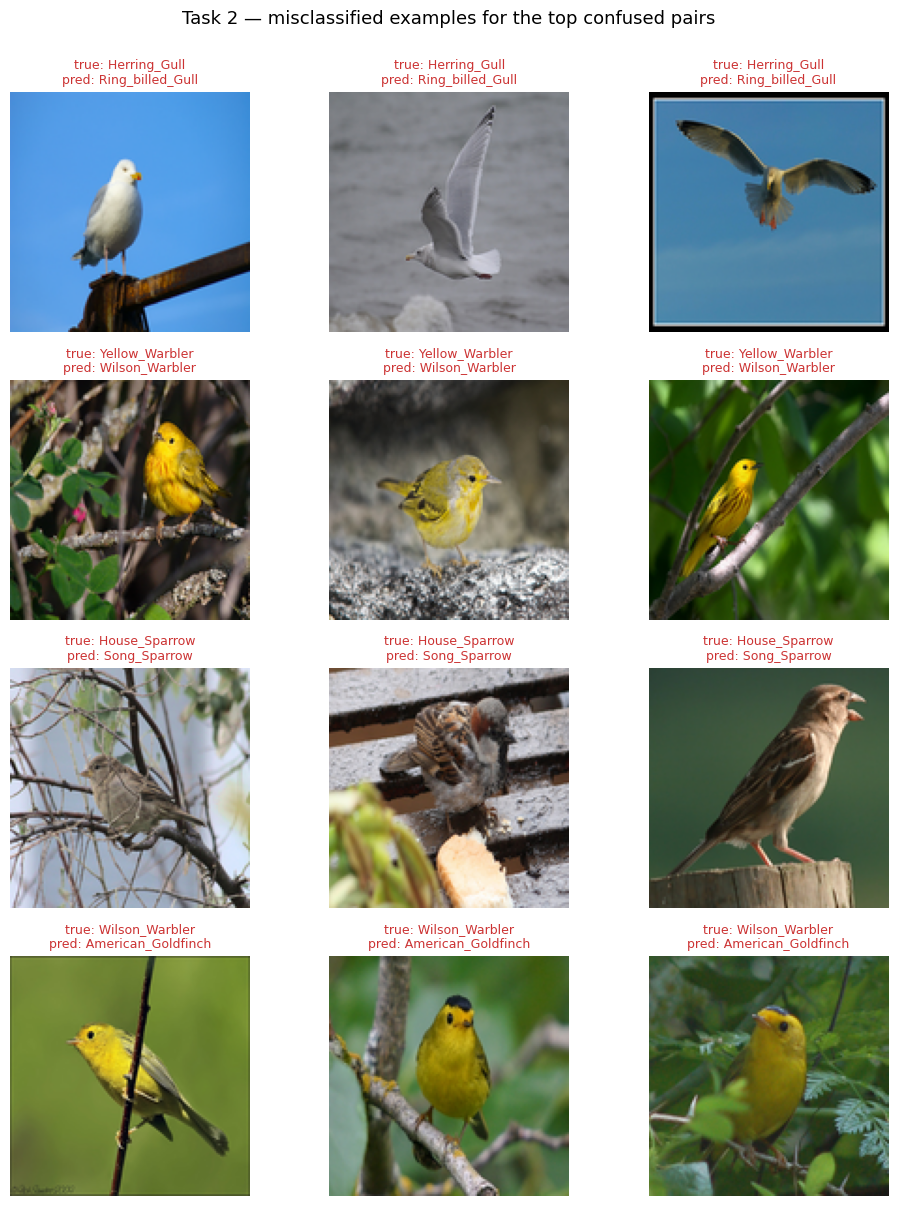

In [27]:
# Pick top 4 distinct confused pairs (not symmetric duplicates)
shown_pairs = []
seen = set()
for _, row in top_t2.iterrows():
    key = frozenset([row['true'], row['pred']])
    if key in seen:
        continue
    seen.add(key)
    shown_pairs.append((row['true'], row['pred']))
    if len(shown_pairs) == 4:
        break

np.random.seed(42)
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
for r, (true_name, pred_name) in enumerate(shown_pairs):
    true_id = class_names_t2.index(true_name)
    pred_id = class_names_t2.index(pred_name)
    mask = (y2 == true_id) & (oof2 == pred_id)
    indices = np.where(mask)[0]
    chosen = np.random.choice(indices, size=min(3, len(indices)), replace=False)
    for c, idx in enumerate(chosen):
        img_path = TASK2_DIR + "/" + train_meta_t2.iloc[idx]["image_path"]
        img = Image.open(img_path).convert("RGB")
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        axes[r, c].set_title(f"true: {true_name}\npred: {pred_name}", fontsize=9, color='#cc3333')
    for c in range(len(chosen), 3):
        axes[r, c].axis('off')

fig.suptitle("Task 2 — misclassified examples for the top confused pairs", y=1.001, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_task2_misclassified.png", dpi=120, bbox_inches="tight")
plt.show()

## Phase 6 — Kaggle test submissions

Refit the best model per task on the full training set and predict on the test set.

- Task 1: Logistic Regression on `cnn_only` → `outputs/task1_submission.csv`
- Task 2: Random Forest on `cnn_plus_trad` → `outputs/task2_submission.csv`

In [28]:
# === Task 1: refit LR on full training data, predict test ===
print("Refitting Task 1 best model (LR + cnn_only) on full 3750 train samples...")
scaler_final_t1 = StandardScaler()
X1_cnn_full_s = scaler_final_t1.fit_transform(X1_cnn)
X1_cnn_test_s = scaler_final_t1.transform(X1_cnn_test_arr)

best_t1 = LogisticRegression(C=1.0, max_iter=3000, random_state=42)
best_t1.fit(X1_cnn_full_s, y1)
preds_t1 = best_t1.predict(X1_cnn_test_s)

sub_t1 = pd.DataFrame({
    "image_id": test_meta_t1["image_id"].values,
    "class_id": preds_t1.astype(int),
})
sub_t1_path = PROJECT_ROOT + "/outputs/task1_submission.csv"
sub_t1.to_csv(sub_t1_path, index=False)
print(f"Saved {sub_t1_path}")
print(f"Shape: {sub_t1.shape}")
print(sub_t1.head())

Refitting Task 1 best model (LR + cnn_only) on full 3750 train samples...


Saved D:/2026S1/COMP30027/Assignment2/outputs/task1_submission.csv
Shape: (1250, 2)
     image_id  class_id
0  test_00000         9
1  test_00001         9
2  test_00002         9
3  test_00003         7
4  test_00004         7


In [29]:
# === Task 2: refit RF on full training data with CNN + traditional features ===
print("Refitting Task 2 best model (RF + cnn+trad) on full 417 train samples...")
best_t2 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
best_t2.fit(X2_cnn_plus_trad, y2)
preds_t2 = best_t2.predict(X2_cnn_plus_trad_test)

sub_t2 = pd.DataFrame({
    "image_id": test_meta_t2["image_id"].values,
    "class_id": preds_t2.astype(int),
})
sub_t2_path = PROJECT_ROOT + "/outputs/task2_submission.csv"
sub_t2.to_csv(sub_t2_path, index=False)
print(f"Saved {sub_t2_path}")
print(f"Shape: {sub_t2.shape}")
print(sub_t2.head())

Refitting Task 2 best model (RF + cnn+trad) on full 417 train samples...


Saved D:/2026S1/COMP30027/Assignment2/outputs/task2_submission.csv
Shape: (180, 2)
    image_id  class_id
0  test_0000         9
1  test_0001         2
2  test_0002         0
3  test_0003         2
4  test_0004         0


### 6.1 Sanity check: distribution of predicted classes

A degenerate model would predict the same class for everything. Healthy predictions should approximately follow the training class distribution.

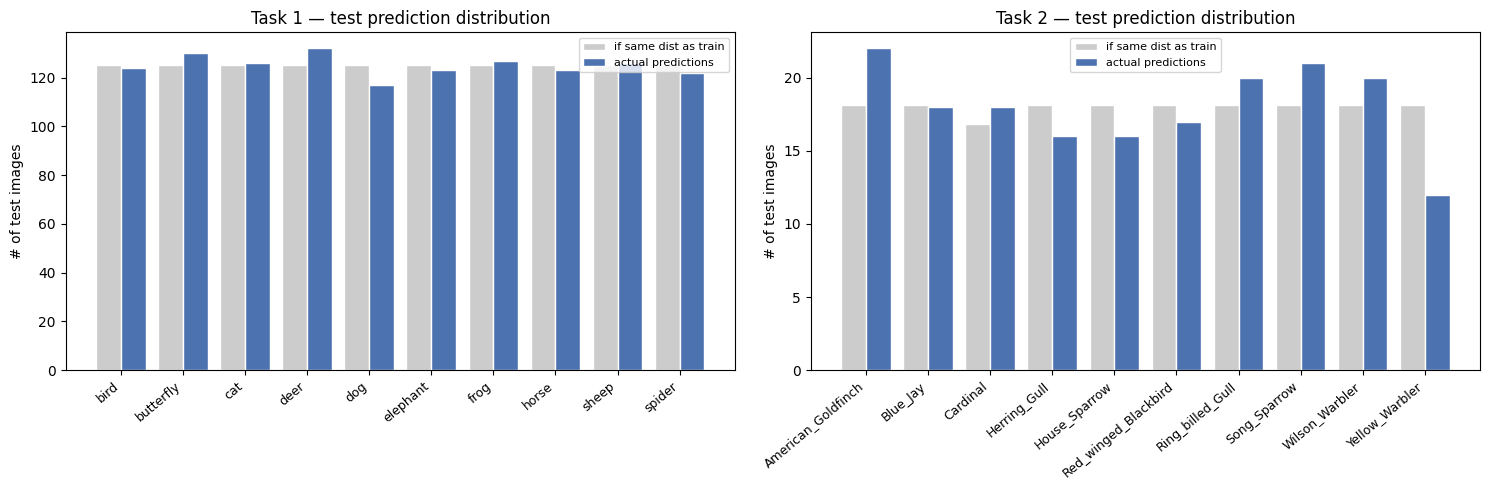


Task 1: predicted 10 distinct classes out of 10
Task 2: predicted 10 distinct classes out of 10


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Task 1
expected_t1 = np.bincount(y1, minlength=10) / len(y1) * len(sub_t1)
actual_t1 = np.bincount(preds_t1, minlength=10)
x = np.arange(10)
w = 0.4
axes[0].bar(x - w/2, expected_t1, width=w, label='if same dist as train', color='#cccccc', edgecolor='white')
axes[0].bar(x + w/2, actual_t1,   width=w, label='actual predictions',   color='#4C72B0', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names_t1, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel("# of test images")
axes[0].set_title("Task 1 — test prediction distribution")
axes[0].legend(fontsize=8)

# Task 2
expected_t2 = np.bincount(y2, minlength=10) / len(y2) * len(sub_t2)
actual_t2 = np.bincount(preds_t2, minlength=10)
axes[1].bar(x - w/2, expected_t2, width=w, label='if same dist as train', color='#cccccc', edgecolor='white')
axes[1].bar(x + w/2, actual_t2,   width=w, label='actual predictions',   color='#4C72B0', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names_t2, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel("# of test images")
axes[1].set_title("Task 2 — test prediction distribution")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR + "/fig_test_pred_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTask 1: predicted {len(set(preds_t1))} distinct classes out of 10")
print(f"Task 2: predicted {len(set(preds_t2))} distinct classes out of 10")